# MURA Body Part Classification (7-Class X-Ray Classifier)

**Pipeline:** Data Exploration → Dataset & Transforms → Model (DenseNet-169 Transfer Learning) → Training → Evaluation & Visualization

**Classes:** ELBOW, FINGER, FOREARM, HAND, HUMERUS, SHOULDER, WRIST

In [1]:
# -- Cell 1: Imports & Device Setup ------------------------------------------

import os
import time
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import transforms, models
from torch.utils.data import Dataset, DataLoader
from torch.optim.lr_scheduler import StepLR
from PIL import Image
from sklearn.metrics import confusion_matrix, classification_report

# Device setup (following main.py pattern)
use_accel = torch.accelerator.is_available()
if use_accel:
    device = torch.accelerator.current_accelerator()
else:
    device = torch.device("cpu")

# Constants
DATA_ROOT   = "./mura_downloads"
NUM_CLASSES = 7
BATCH_SIZE  = 32
NUM_EPOCHS  = 15
LR          = 1e-4
GAMMA       = 0.7
SEED        = 42
MODEL_PATH  = "./mura_bodypart_classifier.pth"

torch.manual_seed(SEED)

print(f"Device: {device}")

print(f"Batch size: {BATCH_SIZE}, Epochs: {NUM_EPOCHS}, LR: {LR}")

Device: cpu
Batch size: 32, Epochs: 15, LR: 0.0001


In [3]:
# -- Cell 2: Data Exploration -------------------------------------------------

CLASS_NAMES = sorted(['ELBOW', 'FINGER', 'FOREARM', 'HAND', 'HUMERUS', 'SHOULDER', 'WRIST'])
CLASS_TO_IDX = {name: i for i, name in enumerate(CLASS_NAMES)}

def count_images(split_dir):
    counts = {}
    for body_part in CLASS_NAMES:
        folder = os.path.join(split_dir, f"XR_{body_part}")
        n = sum(1 for _, _, files in os.walk(folder) for f in files if f.endswith('.png'))
        counts[body_part] = n
    return counts

train_counts = count_images(os.path.join(DATA_ROOT, "train"))
valid_counts = count_images(os.path.join(DATA_ROOT, "valid"))

print(f"{'Body Part':<12} {'Train':>8} {'Valid':>8}")
print("-" * 30)
for name in CLASS_NAMES:
    print(f"{name:<12} {train_counts[name]:>8} {valid_counts[name]:>8}")
print("-" * 30)
print(f"{'TOTAL':<12} {sum(train_counts.values()):>8} {sum(valid_counts.values()):>8}")

Body Part       Train    Valid
------------------------------
ELBOW            4931      465
FINGER           5106      461
FOREARM          1825      301
HAND             5543      460
HUMERUS          1272      288
SHOULDER         8379      563
WRIST            9756      659
------------------------------
TOTAL           36812     3197


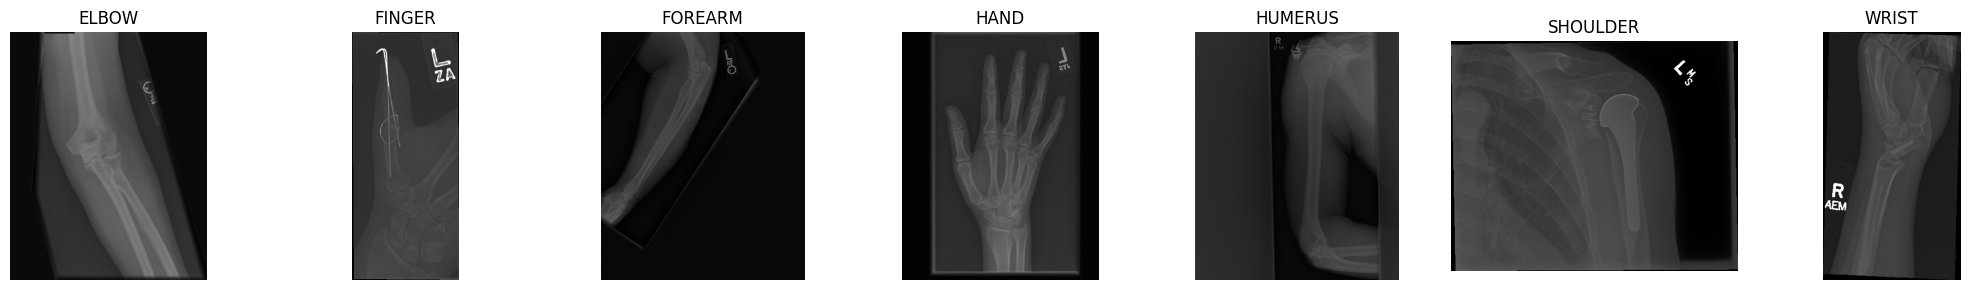

In [3]:
# -- Cell 3: Sample Image Visualization --------------------------------------

fig, axes = plt.subplots(1, 7, figsize=(21, 3))
for ax, name in zip(axes, CLASS_NAMES):
    folder = os.path.join(DATA_ROOT, "train", f"XR_{name}")
    # Find the first .png image
    img_path = None
    for root, dirs, files in os.walk(folder):
        for f in files:
            if f.endswith('.png'):
                img_path = os.path.join(root, f)
                break
        if img_path:
            break
    img = Image.open(img_path)
    ax.imshow(img, cmap='gray')
    ax.set_title(name)
    ax.axis('off')
plt.tight_layout()
plt.show()

In [4]:
# -- Cell 4: Dataset & Transforms ---------------------------------------------

import torchvision.transforms.functional as TF

class LetterboxResize:
    """Resize preserving aspect ratio, then pad to target square with zeros."""
    def __init__(self, size=224):
        self.size = size

    def __call__(self, img):
        w, h = img.size
        scale = self.size / max(w, h)
        new_w = int(w * scale)
        new_h = int(h * scale)
        img = img.resize((new_w, new_h), Image.BILINEAR)
        pad_w = self.size - new_w
        pad_h = self.size - new_h
        left   = pad_w // 2
        right  = pad_w - left
        top    = pad_h // 2
        bottom = pad_h - top
        return TF.pad(img, (left, top, right, bottom), fill=0)


class MURABodyPartDataset(Dataset):
    def __init__(self, root_dir, split, transform=None):
        self.transform = transform
        self.image_paths = []
        self.labels = []

        split_dir = os.path.join(root_dir, split)
        for body_part in CLASS_NAMES:
            label = CLASS_TO_IDX[body_part]
            folder = os.path.join(split_dir, f"XR_{body_part}")
            for root, dirs, files in os.walk(folder):
                for f in files:
                    if f.endswith('.png') and not f.startswith('._'):
                        self.image_paths.append(os.path.join(root, f))
                        self.labels.append(label)

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        image = Image.open(self.image_paths[idx]).convert('RGB')
        label = self.labels[idx]
        if self.transform:
            image = self.transform(image)
        return image, label

train_transform = transforms.Compose([
    LetterboxResize(224),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

valid_transform = transforms.Compose([
    LetterboxResize(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

train_dataset = MURABodyPartDataset(DATA_ROOT, "train", train_transform)
valid_dataset = MURABodyPartDataset(DATA_ROOT, "valid", valid_transform)

print(f"Train dataset: {len(train_dataset)} images")
print(f"Valid dataset: {len(valid_dataset)} images")


Train dataset: 36808 images
Valid dataset: 3197 images


In [5]:
# -- Cell 5: DataLoaders & Class Weights --------------------------------------

# Inverse-frequency class weights to handle imbalance
label_counts = Counter(train_dataset.labels)
total = len(train_dataset.labels)
class_weights = torch.tensor(
    [total / (NUM_CLASSES * label_counts[i]) for i in range(NUM_CLASSES)],
    dtype=torch.float32
).to(device)

print("Class weights:")
for i, name in enumerate(CLASS_NAMES):
    print(f"  {name:<12} count={label_counts[i]:>6}  weight={class_weights[i]:.3f}")

loader_kwargs = {
    'batch_size': BATCH_SIZE,
    'num_workers': 4,
    'persistent_workers': False,
    'pin_memory': False,
}
train_loader = DataLoader(train_dataset, shuffle=True, **loader_kwargs)
valid_loader = DataLoader(valid_dataset, shuffle=False, **loader_kwargs)

print(f"\nTrain batches: {len(train_loader)}, Valid batches: {len(valid_loader)}")


Class weights:
  ELBOW        count=  4931  weight=1.066
  FINGER       count=  5106  weight=1.030
  FOREARM      count=  1825  weight=2.881
  HAND         count=  5543  weight=0.949
  HUMERUS      count=  1272  weight=4.134
  SHOULDER     count=  8379  weight=0.628
  WRIST        count=  9752  weight=0.539

Train batches: 1151, Valid batches: 100


In [6]:
# -- Cell 6: Model (DenseNet-169 Transfer Learning) --------------------------

model = models.densenet169(weights=models.DenseNet169_Weights.IMAGENET1K_V1)
num_ftrs = model.classifier.in_features
model.classifier = nn.Linear(num_ftrs, NUM_CLASSES)
model = model.to(device)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"DenseNet-169: {total_params:,} total params, {trainable_params:,} trainable")

DenseNet-169: 12,496,135 total params, 12,496,135 trainable


In [7]:
# -- Cell 7: Loss, Optimizer & Scheduler --------------------------------------

criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = optim.Adam(model.parameters(), lr=LR)
scheduler = StepLR(optimizer, step_size=5, gamma=GAMMA)

print(f"Loss: CrossEntropyLoss (weighted)")
print(f"Optimizer: Adam (lr={LR})")
print(f"Scheduler: StepLR (step_size=5, gamma={GAMMA})")

Loss: CrossEntropyLoss (weighted)
Optimizer: Adam (lr=0.0001)
Scheduler: StepLR (step_size=5, gamma=0.7)


In [ ]:
# -- Cell 8: Training ---------------------------------------------------------

best_val_acc = 0.0
train_losses, val_losses = [], []
train_accs, val_accs = [], []
epoch_times = []

for epoch in range(1, NUM_EPOCHS + 1):
    if torch.cuda.is_available():
        torch.cuda.synchronize()
    start_time = time.time()

    # --- Train phase ---
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for batch_idx, (images, labels) in enumerate(train_loader):
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

        if batch_idx % 100 == 0:
            print(f'Train Epoch: {epoch} [{batch_idx * len(images)}/{len(train_loader.dataset)} '
                  f'({100. * batch_idx / len(train_loader):.0f}%)]\tLoss: {loss.item():.6f}')

    train_loss = running_loss / total
    train_acc = 100. * correct / total
    train_losses.append(train_loss)
    train_accs.append(train_acc)

    # --- Validation phase ---
    model.eval()
    val_running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in valid_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_running_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

    val_loss = val_running_loss / total
    val_acc = 100. * correct / total
    val_losses.append(val_loss)
    val_accs.append(val_acc)

    scheduler.step()

    if torch.cuda.is_available():
        torch.cuda.synchronize()
    duration = time.time() - start_time
    epoch_times.append(duration)

    # Save best model
    tag = ""
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), MODEL_PATH)
        tag = " <- saved"

    print(f'Epoch [{epoch:2d}/{NUM_EPOCHS}]  '
          f'Train Loss: {train_loss:.4f}  Train Acc: {train_acc:.1f}%  '
          f'Val Loss: {val_loss:.4f}  Val Acc: {val_acc:.1f}%  '
          f'Time: {duration:.1f}s{tag}')

# Final timing summary
if epoch_times:
    print(f'\n[FINAL] Total Training Time: {sum(epoch_times):.3f}s')
    print(f'[FINAL] Average Per-Epoch Time: {sum(epoch_times)/len(epoch_times):.3f}s')
    print(f'[FINAL] Best Validation Accuracy: {best_val_acc:.1f}%')

Train Epoch: 1 [0/36808 (0%)]	Loss: 1.933721
Train Epoch: 1 [3200/36808 (9%)]	Loss: 0.216176
Train Epoch: 1 [6400/36808 (17%)]	Loss: 0.066414
Train Epoch: 1 [9600/36808 (26%)]	Loss: 0.119428
Train Epoch: 1 [12800/36808 (35%)]	Loss: 0.100991
Train Epoch: 1 [16000/36808 (43%)]	Loss: 0.111964
Train Epoch: 1 [19200/36808 (52%)]	Loss: 0.247115
Train Epoch: 1 [22400/36808 (61%)]	Loss: 0.036332
Train Epoch: 1 [25600/36808 (70%)]	Loss: 0.042318
Train Epoch: 1 [28800/36808 (78%)]	Loss: 0.077760
Train Epoch: 1 [32000/36808 (87%)]	Loss: 0.071980
Train Epoch: 1 [35200/36808 (96%)]	Loss: 0.051624
Epoch [ 1/15]  Train Loss: 0.2074  Train Acc: 95.2%  Val Loss: 0.1505  Val Acc: 95.8%  Time: 6713.5s <- saved
Train Epoch: 2 [0/36808 (0%)]	Loss: 0.014384
Train Epoch: 2 [3200/36808 (9%)]	Loss: 0.085365
Train Epoch: 2 [6400/36808 (17%)]	Loss: 0.323934
Train Epoch: 2 [9600/36808 (26%)]	Loss: 0.373098
Train Epoch: 2 [12800/36808 (35%)]	Loss: 0.216907
Train Epoch: 2 [16000/36808 (43%)]	Loss: 0.063593
Train Ep

ValueError: x and y must have same first dimension, but have shapes (15,) and (1,)

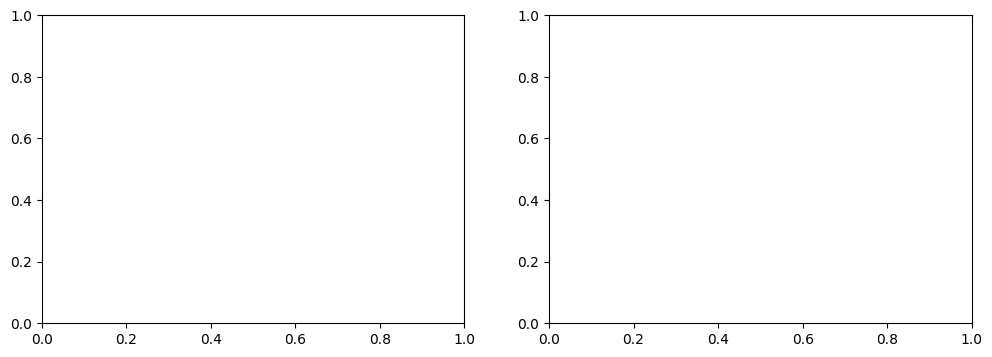

In [ ]:
# -- Cell 9: Training Curves --------------------------------------------------

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(range(1, NUM_EPOCHS + 1), train_losses, label='Train')
ax1.plot(range(1, NUM_EPOCHS + 1), val_losses, label='Valid')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Loss Curves')
ax1.legend()

ax2.plot(range(1, NUM_EPOCHS + 1), train_accs, label='Train')
ax2.plot(range(1, NUM_EPOCHS + 1), val_accs, label='Valid')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.set_title('Accuracy Curves')
ax2.legend()

plt.tight_layout()
plt.savefig("mura_training_curves.pdf", format='pdf', bbox_inches='tight', dpi=300)
plt.show()

In [2]:
# -- Cell 10: Evaluation — Per-Class Accuracy & Classification Report --------

model.load_state_dict(torch.load(MODEL_PATH, map_location=device, weights_only=True))
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in valid_loader:
        images = images.to(device)
        outputs = model(images)
        _, predicted = outputs.max(1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

print(classification_report(all_labels, all_preds, target_names=CLASS_NAMES))

print("\nPer-class accuracy:")
for i, name in enumerate(CLASS_NAMES):
    mask = all_labels == i
    class_correct = (all_preds[mask] == i).sum()
    class_total = mask.sum()
    print(f'  {name:<12}: {class_correct}/{class_total} ({100. * class_correct / class_total:.1f}%)')

NameError: name 'model' is not defined

/tmp/ipykernel_39909/2930463571.py:5: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  im = ax.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
/tmp/ipykernel_39909/2930463571.py:5: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  im = ax.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)


ValueError: zero-size array to reduction operation maximum which has no identity

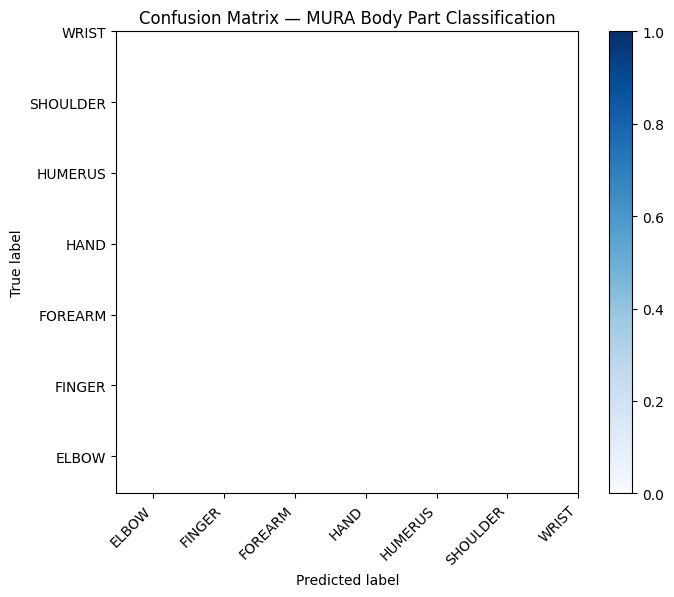

In [ ]:
# -- Cell 11: Confusion Matrix ------------------------------------------------

cm = confusion_matrix(all_labels, all_preds)
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
ax.figure.colorbar(im, ax=ax)
ax.set(xticks=range(NUM_CLASSES), yticks=range(NUM_CLASSES),
       xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
       ylabel='True label', xlabel='Predicted label',
       title='Confusion Matrix — MURA Body Part Classification')
plt.setp(ax.get_xticklabels(), rotation=45, ha='right')

thresh = cm.max() / 2.
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, format(cm[i, j], 'd'),
                ha='center', va='center',
                color='white' if cm[i, j] > thresh else 'black')

plt.tight_layout()
plt.savefig("mura_confusion_matrix.pdf", format='pdf', bbox_inches='tight', dpi=300)
plt.show()

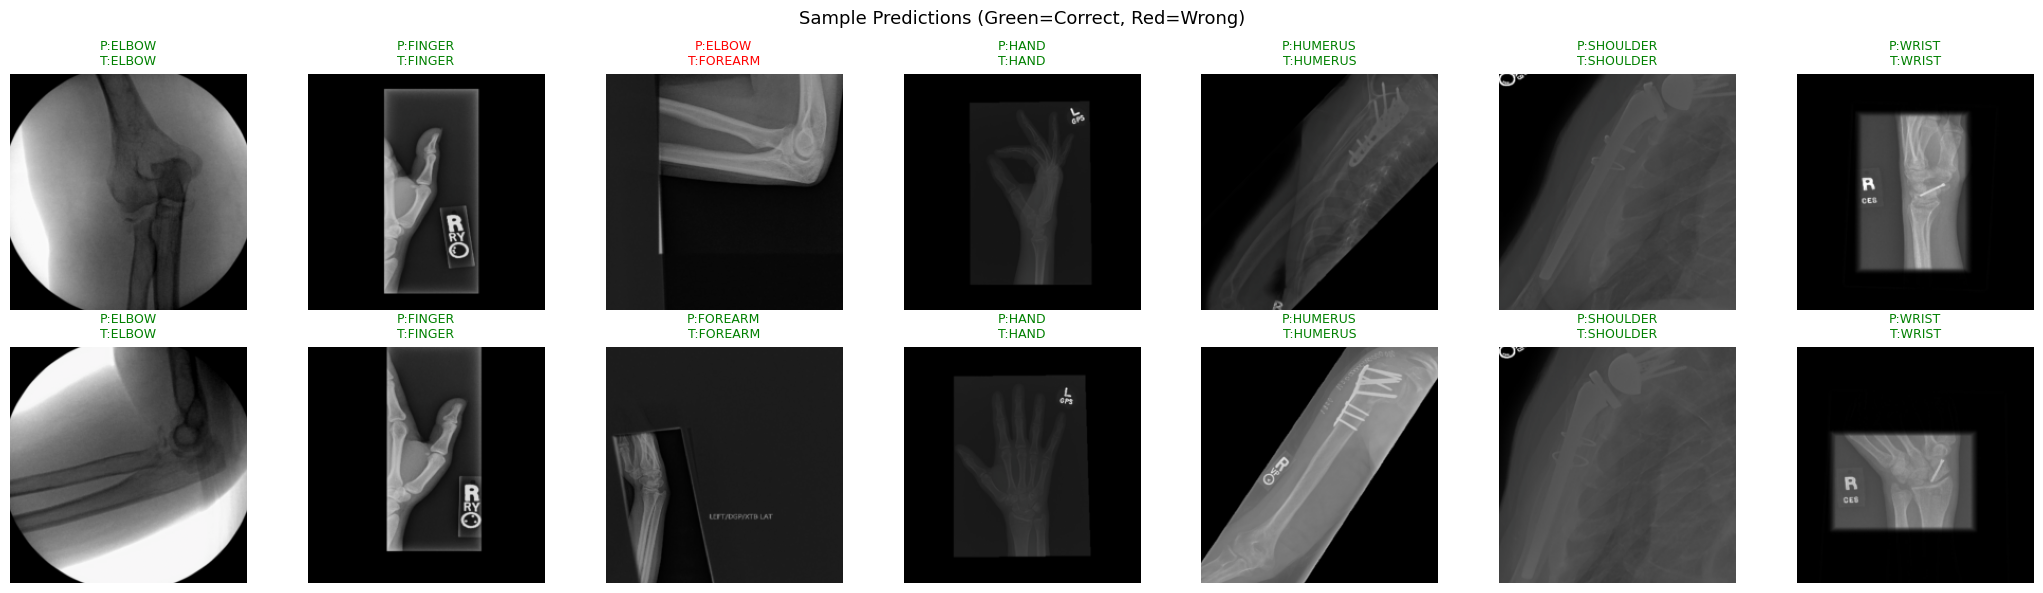

In [ ]:
# -- Cell 12: Sample Predictions ----------------------------------------------

def denormalize(tensor):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    return (tensor * std + mean).clamp(0, 1)

# Collect 2 sample images per class from validation set
samples_per_class = {i: [] for i in range(NUM_CLASSES)}
for idx in range(len(valid_dataset)):
    _, label = valid_dataset[idx]
    if len(samples_per_class[label]) < 2:
        samples_per_class[label].append(idx)
    if all(len(v) >= 2 for v in samples_per_class.values()):
        break

fig, axes = plt.subplots(2, 7, figsize=(21, 6))
model.eval()
with torch.no_grad():
    for cls_idx in range(NUM_CLASSES):
        for row, sample_idx in enumerate(samples_per_class[cls_idx]):
            img_tensor, true_label = valid_dataset[sample_idx]
            output = model(img_tensor.unsqueeze(0).to(device))
            pred_label = output.argmax(1).item()

            img_display = denormalize(img_tensor).permute(1, 2, 0).numpy()
            ax = axes[row, cls_idx]
            ax.imshow(img_display)
            correct = pred_label == true_label
            color = 'green' if correct else 'red'
            ax.set_title(f'P:{CLASS_NAMES[pred_label]}\nT:{CLASS_NAMES[true_label]}',
                         color=color, fontsize=9)
            ax.axis('off')

plt.suptitle('Sample Predictions (Green=Correct, Red=Wrong)', fontsize=13)
plt.tight_layout()
plt.show()

Body Part     Avg Sparsity (=0)   Avg Sparsity (<=5)  Max Sparsity (=0)
------------------------------------------------------------------------
ELBOW                    7.16%              15.09%            88.74%
FINGER                   9.18%              23.08%            84.24%
FOREARM                  6.99%              19.77%            86.38%
HAND                     4.52%              10.03%            76.01%
HUMERUS                 18.06%              23.48%            75.56%
SHOULDER                 6.31%              12.45%            82.90%
WRIST                    5.13%              17.01%            85.47%


/tmp/ipykernel_39909/33701305.py:48: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax1.boxplot(data_exact, labels=CLASS_NAMES)
/tmp/ipykernel_39909/33701305.py:53: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax2.boxplot(data_near, labels=CLASS_NAMES)


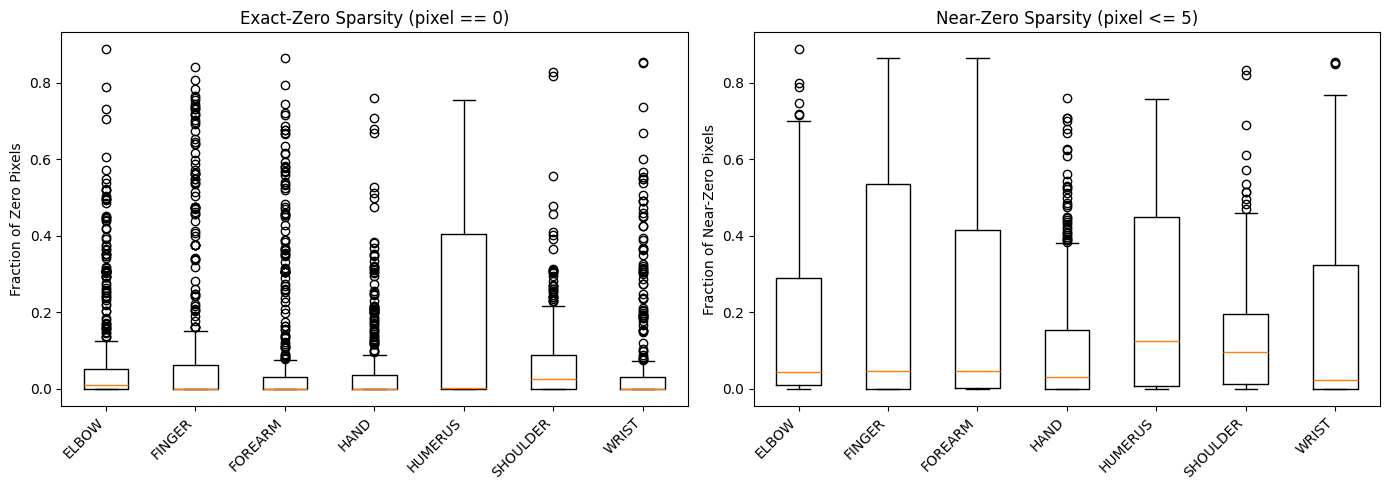


Overall (sampled 3500 images):
  Exact-zero sparsity: mean=8.19%, median=0.09%, std=16.26%
  Near-zero sparsity:  mean=17.27%, median=4.91%, std=22.48%


In [ ]:
# -- Cell 14: Sparsity Analysis -----------------------------------------------
# Sparsity = fraction of zero-valued pixels in the raw (unnormalized) image.
# Also reports near-zero sparsity (pixel value <= 5 out of 255).

import random

sparsity_stats = defaultdict(lambda: {'exact_zero': [], 'near_zero': []})

random.seed(SEED)
SAMPLE_PER_CLASS = 500  # sample for speed; set to None for exhaustive

for split in ['train']:
    split_dir = os.path.join(DATA_ROOT, split)
    for body_part in CLASS_NAMES:
        folder = os.path.join(split_dir, f"XR_{body_part}")
        paths = []
        for root, dirs, files in os.walk(folder):
            for f in files:
                if f.endswith('.png') and not f.startswith('._'):
                    paths.append(os.path.join(root, f))

        if SAMPLE_PER_CLASS and len(paths) > SAMPLE_PER_CLASS:
            paths = random.sample(paths, SAMPLE_PER_CLASS)

        for p in paths:
            arr = np.array(Image.open(p).convert('L'), dtype=np.uint8)
            total_px = arr.size
            exact_zero = np.count_nonzero(arr == 0) / total_px
            near_zero = np.count_nonzero(arr <= 5) / total_px
            sparsity_stats[body_part]['exact_zero'].append(exact_zero)
            sparsity_stats[body_part]['near_zero'].append(near_zero)

print(f"{'Body Part':<12} {'Avg Sparsity (=0)':>18} {'Avg Sparsity (<=5)':>20} {'Max Sparsity (=0)':>18}")
print("-" * 72)
for name in CLASS_NAMES:
    s = sparsity_stats[name]
    avg_exact = np.mean(s['exact_zero'])
    avg_near = np.mean(s['near_zero'])
    max_exact = np.max(s['exact_zero'])
    print(f"{name:<12} {avg_exact:>17.2%} {avg_near:>19.2%} {max_exact:>17.2%}")

# Box plot of exact-zero sparsity per class
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

data_exact = [sparsity_stats[name]['exact_zero'] for name in CLASS_NAMES]
data_near = [sparsity_stats[name]['near_zero'] for name in CLASS_NAMES]

ax1.boxplot(data_exact, labels=CLASS_NAMES)
ax1.set_ylabel('Fraction of Zero Pixels')
ax1.set_title('Exact-Zero Sparsity (pixel == 0)')
plt.setp(ax1.get_xticklabels(), rotation=45, ha='right')

ax2.boxplot(data_near, labels=CLASS_NAMES)
ax2.set_ylabel('Fraction of Near-Zero Pixels')
ax2.set_title('Near-Zero Sparsity (pixel <= 5)')
plt.setp(ax2.get_xticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()

# Overall summary
all_exact = [v for name in CLASS_NAMES for v in sparsity_stats[name]['exact_zero']]
all_near = [v for name in CLASS_NAMES for v in sparsity_stats[name]['near_zero']]
print(f"\nOverall (sampled {len(all_exact)} images):")
print(f"  Exact-zero sparsity: mean={np.mean(all_exact):.2%}, median={np.median(all_exact):.2%}, std={np.std(all_exact):.2%}")
print(f"  Near-zero sparsity:  mean={np.mean(all_near):.2%}, median={np.median(all_near):.2%}, std={np.std(all_near):.2%}")

Body Part      Avg W   Avg H   Avg Pixels   Min Pixels   Max Pixels
-----------------------------------------------------------------
ELBOW            409     490      198,057       84,992      262,144
FINGER           333     499      163,786       45,568      262,144
FOREARM          419     465      190,529       59,904      262,144
HAND             398     505      200,259       81,920      262,144
HUMERUS          440     498      218,447       83,968      262,144
SHOULDER         459     467      211,705       77,824      262,144
WRIST            370     503      185,098       67,072      262,144


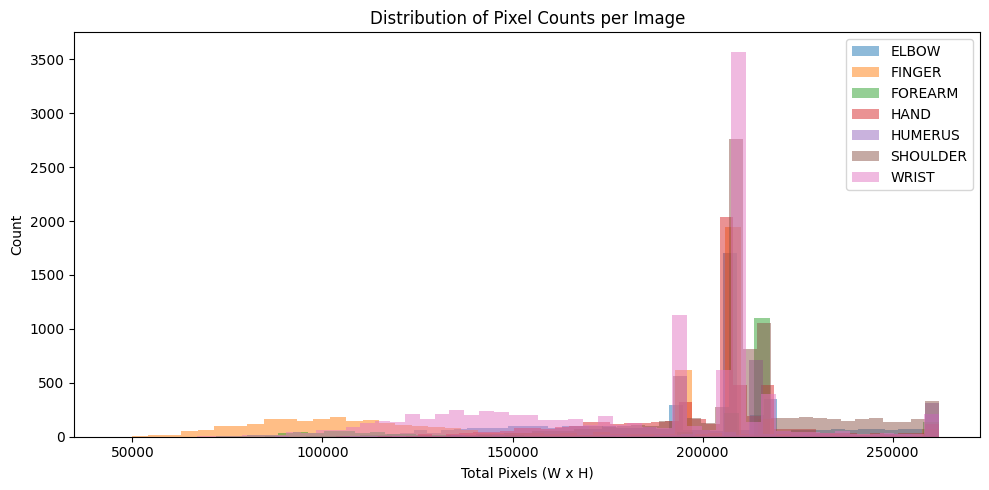

In [ ]:
# -- Cell 13: Pixel Count & Image Dimensions Per Class ------------------------

from collections import defaultdict

dim_stats = defaultdict(lambda: {'widths': [], 'heights': [], 'pixels': []})

for split in ['train', 'valid']:
    split_dir = os.path.join(DATA_ROOT, split)
    for body_part in CLASS_NAMES:
        folder = os.path.join(split_dir, f"XR_{body_part}")
        for root, dirs, files in os.walk(folder):
            for f in files:
                if f.endswith('.png') and not f.startswith('._'):
                    img = Image.open(os.path.join(root, f))
                    w, h = img.size
                    dim_stats[body_part]['widths'].append(w)
                    dim_stats[body_part]['heights'].append(h)
                    dim_stats[body_part]['pixels'].append(w * h)

print(f"{'Body Part':<12} {'Avg W':>7} {'Avg H':>7} {'Avg Pixels':>12} {'Min Pixels':>12} {'Max Pixels':>12}")
print("-" * 65)
for name in CLASS_NAMES:
    s = dim_stats[name]
    avg_w = np.mean(s['widths'])
    avg_h = np.mean(s['heights'])
    avg_px = np.mean(s['pixels'])
    min_px = np.min(s['pixels'])
    max_px = np.max(s['pixels'])
    print(f"{name:<12} {avg_w:>7.0f} {avg_h:>7.0f} {avg_px:>12,.0f} {min_px:>12,} {max_px:>12,}")

# Histogram of total pixel counts
all_pixels = []
all_class_labels = []
for name in CLASS_NAMES:
    all_pixels.extend(dim_stats[name]['pixels'])
    all_class_labels.extend([name] * len(dim_stats[name]['pixels']))

fig, ax = plt.subplots(figsize=(10, 5))
for name in CLASS_NAMES:
    px = dim_stats[name]['pixels']
    ax.hist(px, bins=50, alpha=0.5, label=name)
ax.set_xlabel('Total Pixels (W x H)')
ax.set_ylabel('Count')
ax.set_title('Distribution of Pixel Counts per Image')
ax.legend()
plt.tight_layout()
plt.show()